# Negotiation Team Analysis

Compares negotiation **win rate** and **payoff** across four P1 strategies, all playing
against a **fixed default `gemma-3-12b-it` opponent (P2)** on identical game setups:

| Strategy | Source | P1 party |
|----------|--------|----------|
| **Default** | `defaultP1_defaultP2` | default gemma-3-12b-it |
| **Self-Refine** | `self_refineP1_defaultP2` (RD) | self-refining gemma-3-12b-it |
| **Team (homo)** | `negotiation_team/*_homo_v1` | gemma-3-12b-it ×3 |
| **Team (hetero)** | `negotiation_team/*_hetero_v1` | gemma-3-12b-it + Ministral-3-14B + Qwen3-14B |


In [20]:
import sys, os, json, glob, warnings
sys.path.insert(0, os.path.abspath("../.."))
sys.path.insert(0, os.path.abspath("../../explorer"))  # for the `analysis` package

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from analysis.common import clean_name, resource_value  # reuse explorer/analysis/common.py

warnings.filterwarnings("ignore")
sns.set_context("poster")
sns.set_palette("colorblind")

LOGS_ROOT = os.path.abspath("../../.logs")
SIZE = "small"
GAMES = ["trading", "buysell", "ultimatum"]
GAME_LABEL = {"trading": "Trading", "buysell": "BuySell", "ultimatum": "Ultimatum"}
STRATEGY_ORDER = ["Default", "Self-Refine", "Team (homo)", "Team (hetero)"]

print("LOGS_ROOT:", LOGS_ROOT, "| exists:", os.path.isdir(LOGS_ROOT))

LOGS_ROOT: /home/adriano/Desktop/MultiAgent-Negotiation/.logs | exists: True


## Payoff helper
Same conventions as `self_refine_analysis.ipynb`.

In [21]:
def payoff_from_summary(game, s):
    """Return (payoff_1, payoff_2) for a completed game's summary.

    - buysell : summary["player_outcome"] = [seller, buyer]
    - trading : net change in total resource value (final - initial)
    - ultimatum: same as trading, then proposer (P1) +100 with no-deal fix (==100 -> 0)
    """
    if game == "buysell":
        outcome = s["player_outcome"]            # [seller, buyer]
        return float(outcome[0]), float(outcome[1])

    d1 = resource_value(s["final_resources"][0]) - resource_value(s["initial_resources"][0])
    d2 = resource_value(s["final_resources"][1]) - resource_value(s["initial_resources"][1])

    if game == "ultimatum":
        d1 += 100
        if d1 == 100:        # no deal -> proposer keeps nothing
            d1 = 0
    return float(d1), float(d2)

## Loaders
One tidy long DataFrame: one row per completed run, P1-focal.

In [22]:
def _iter_game_states(root):
    """Yield (path, summary) for every COMPLETED run under `root`."""
    for path in glob.glob(os.path.join(root, "**", "game_state.json"), recursive=True):
        try:
            with open(path) as f:
                data = json.load(f)
        except Exception:
            continue
        last = data["game_state"][-1]
        if last.get("current_iteration") != "END":
            continue
        summary = last.get("summary")
        if summary is None:          # completed but no usable outcome
            continue
        yield path, summary


def _row(game, strategy, path, summary):
    p1, p2 = payoff_from_summary(game, summary)
    return {"game": game, "strategy": strategy,
            "run_id": os.path.basename(os.path.dirname(path)),
            "payoff_1": p1, "payoff_2": p2}


def load_team(game, variant):
    """variant in {'homo','hetero'} -> rows tagged 'Team (homo)'/'Team (hetero)'."""
    label = f"Team ({variant})"
    root = os.path.join(LOGS_ROOT, "negotiation_team",
                        f"{game}_negotiation_team_{variant}_v1", SIZE)
    return [_row(game, label, p, s) for p, s in _iter_game_states(root)]


def load_baseline(game, cond_suffix, label):
    """Pull gemma-vs-gemma self-play runs for one self_refine condition.

    trading/ultimatum encode the condition in the model-pair folder
    (e.g. ..._self_refineP1_defaultP2); buysell nests it as seller40_buyer60_<cond>.
    Match on: some path segment starts with the gemma-vs-gemma pair AND
    some segment ends with the condition suffix.
    """
    root = os.path.join(LOGS_ROOT, "self_refine", f"{game}_self_refine_v1", SIZE)
    rows = []
    for path, summary in _iter_game_states(root):
        parts = path.split(os.sep)
        has_gemma = any(p.startswith("gemma-3-12b-it_vs_gemma-3-12b-it") for p in parts)
        has_cond = any(p.endswith(cond_suffix) for p in parts)
        if has_gemma and has_cond:
            rows.append(_row(game, label, path, summary))
    return rows


def build_df():
    rows = []
    for game in GAMES:
        rows += load_baseline(game, "defaultP1_defaultP2", "Default")
        rows += load_baseline(game, "self_refineP1_defaultP2", "Self-Refine")
        rows += load_team(game, "homo")
        rows += load_team(game, "hetero")
    df = pd.DataFrame(rows)
    df["win_1"] = df["payoff_1"] > df["payoff_2"]
    df["win_2"] = df["payoff_2"] > df["payoff_1"]
    df["draw"]  = df["payoff_1"] == df["payoff_2"]
    df["strategy"] = pd.Categorical(df["strategy"], categories=STRATEGY_ORDER, ordered=True)
    df["game"] = pd.Categorical(df["game"], categories=GAMES, ordered=True)
    return df


df = build_df()
print("rows:", len(df))
df.head()

rows: 354


,game,strategy,run_id,payoff_1,payoff_2,win_1,win_2,draw
0,trading,Default,1779033809585,-1.0,1.0,False,True,False
1,trading,Default,1779032293732,-2.0,2.0,False,True,False
2,trading,Default,1779034769422,-5.0,5.0,False,True,False
3,trading,Default,1779038398618,2.0,-2.0,True,False,False
4,trading,Default,1779033544421,-8.0,8.0,False,True,False


## Sample sizes
Run counts per game × strategy (the denominators behind every plot below).

In [23]:
counts = df.pivot_table(index="game", columns="strategy", values="run_id",
                        aggfunc="count", observed=True)
counts

strategy,Default,Self-Refine,Team (homo),Team (hetero)
game,,,,
trading,30,29,29,28
buysell,30,29,30,30
ultimatum,30,29,30,30


## P1 win rate
Strict P1 wins (`payoff_1 > payoff_2`) vs default gemma. Draw rate reported below.

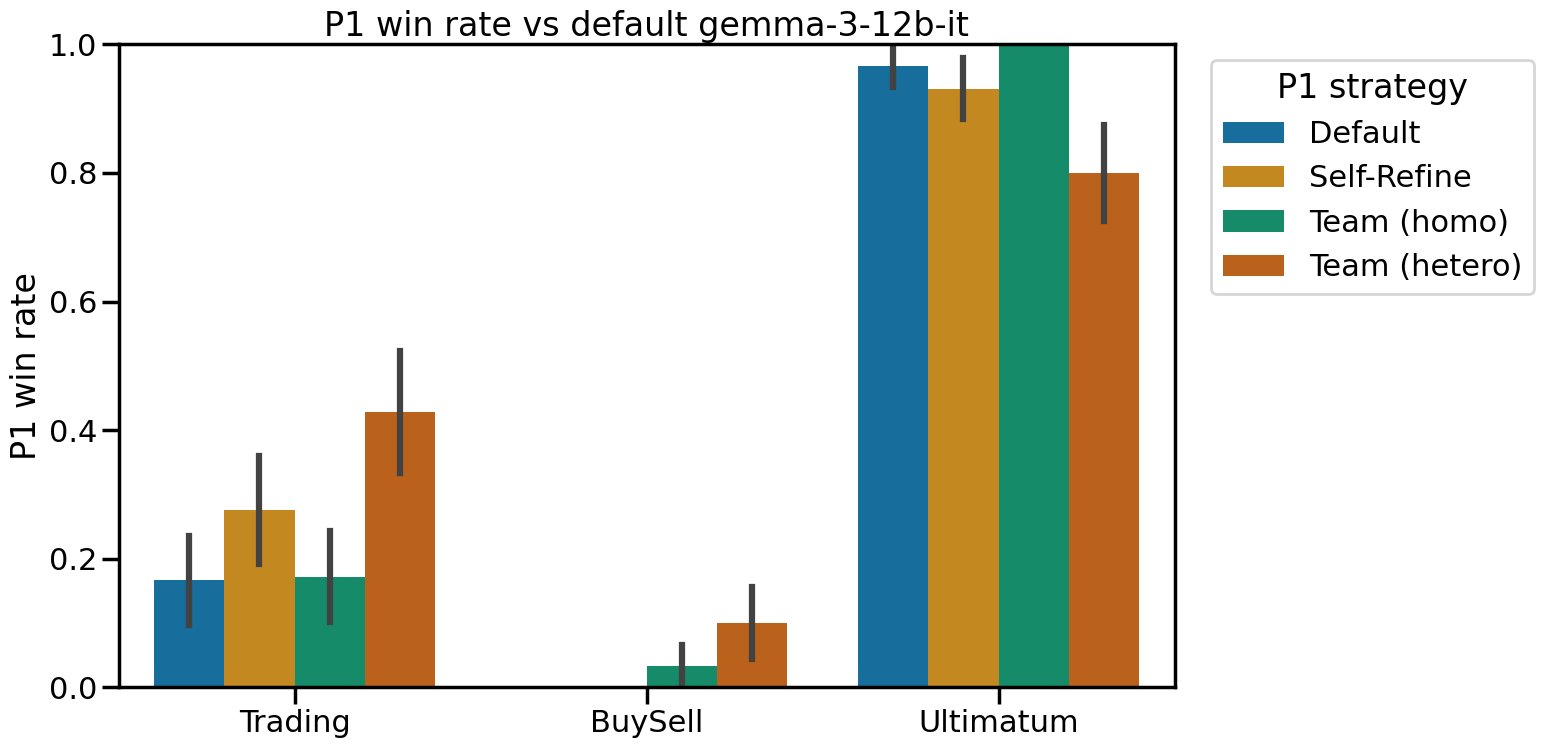

Draw rate per game x strategy:


strategy,Default,Self-Refine,Team (homo),Team (hetero)
game,,,,
trading,0.10,0.03,0.03,0.04
buysell,0.17,0.03,0.03,0.30
ultimatum,0.03,0.07,0.00,0.17


In [24]:
fig, ax = plt.subplots(figsize=(16, 8))
sns.barplot(data=df, x="game", y="win_1", hue="strategy",
            hue_order=STRATEGY_ORDER, errorbar="se", ax=ax)
ax.set_ylabel("P1 win rate")
ax.set_xlabel("")
ax.set_ylim(0, 1)
ax.set_xticklabels([GAME_LABEL[t.get_text()] for t in ax.get_xticklabels()])
ax.set_title("P1 win rate vs default gemma-3-12b-it")
ax.legend(title="P1 strategy", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("Draw rate per game x strategy:")
df.pivot_table(index="game", columns="strategy", values="draw",
               aggfunc="mean", observed=True).round(2)

## P1 payoff 
Payoff scales differ per game, so each game gets its own panel.

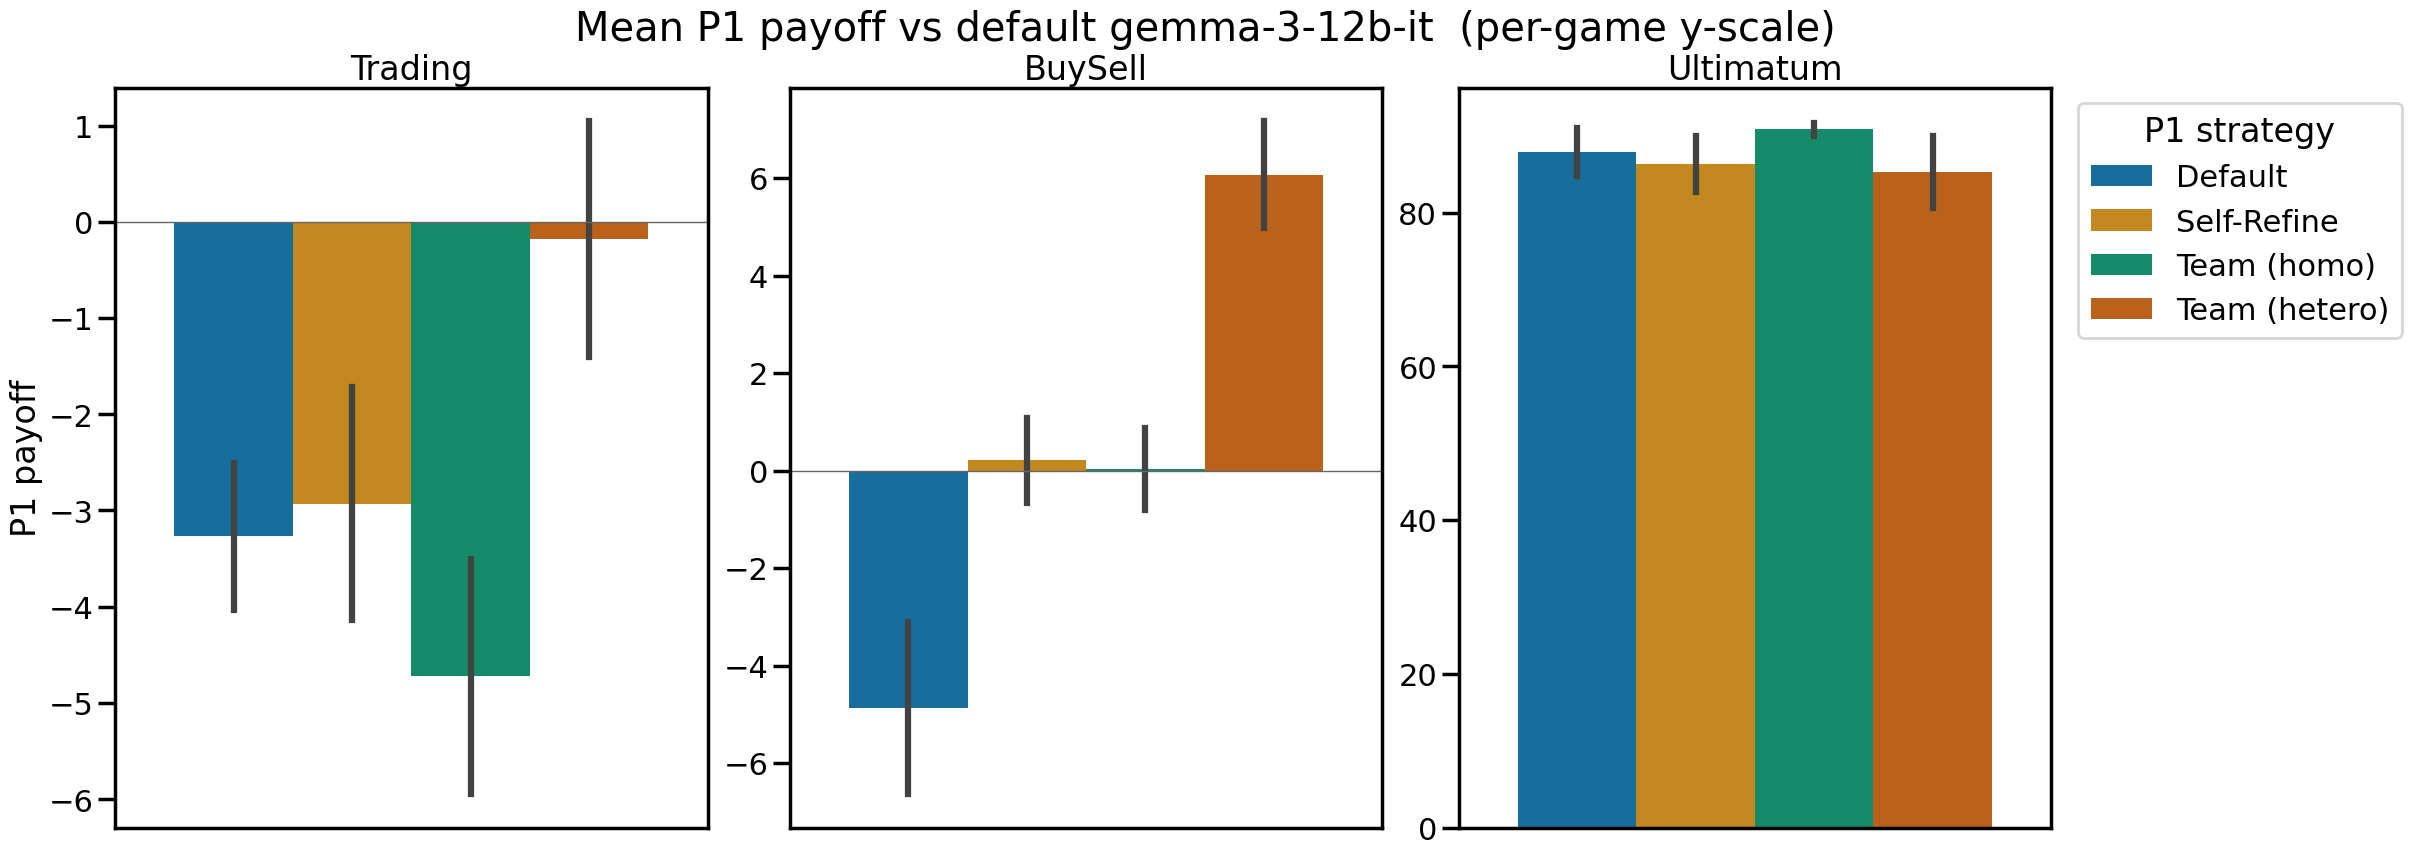

In [ ]:
# Per-game panels (independent y-axes), bars colored by strategy to match the win-rate figure.
fig, axes = plt.subplots(1, 3, figsize=(24, 8), constrained_layout=True)
for ax, game in zip(axes, GAMES):
    sub = df[df["game"] == game].copy()
    sub["game"] = GAME_LABEL[game]  # single string category -> 4 hued bars, centered
    sns.barplot(data=sub, x="game", y="payoff_1", hue="strategy",
                hue_order=STRATEGY_ORDER, errorbar="se", ax=ax,
                legend=(game == GAMES[-1]))
    ax.set_title(GAME_LABEL[game])
    ax.set_xlabel("")
    ax.set_xticks([])
    ax.set_ylabel("P1 payoff" if game == GAMES[0] else "")
    ax.axhline(0, color="0.4", lw=1)  # zero reference (payoffs can be negative)
axes[-1].legend(title="P1 strategy", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("Mean P1 payoff vs default gemma-3-12b-it ", y=1.05)
plt.show()

## Homogeneous vs Heterogeneous teams
Zoom on the two team strategies across the three games.

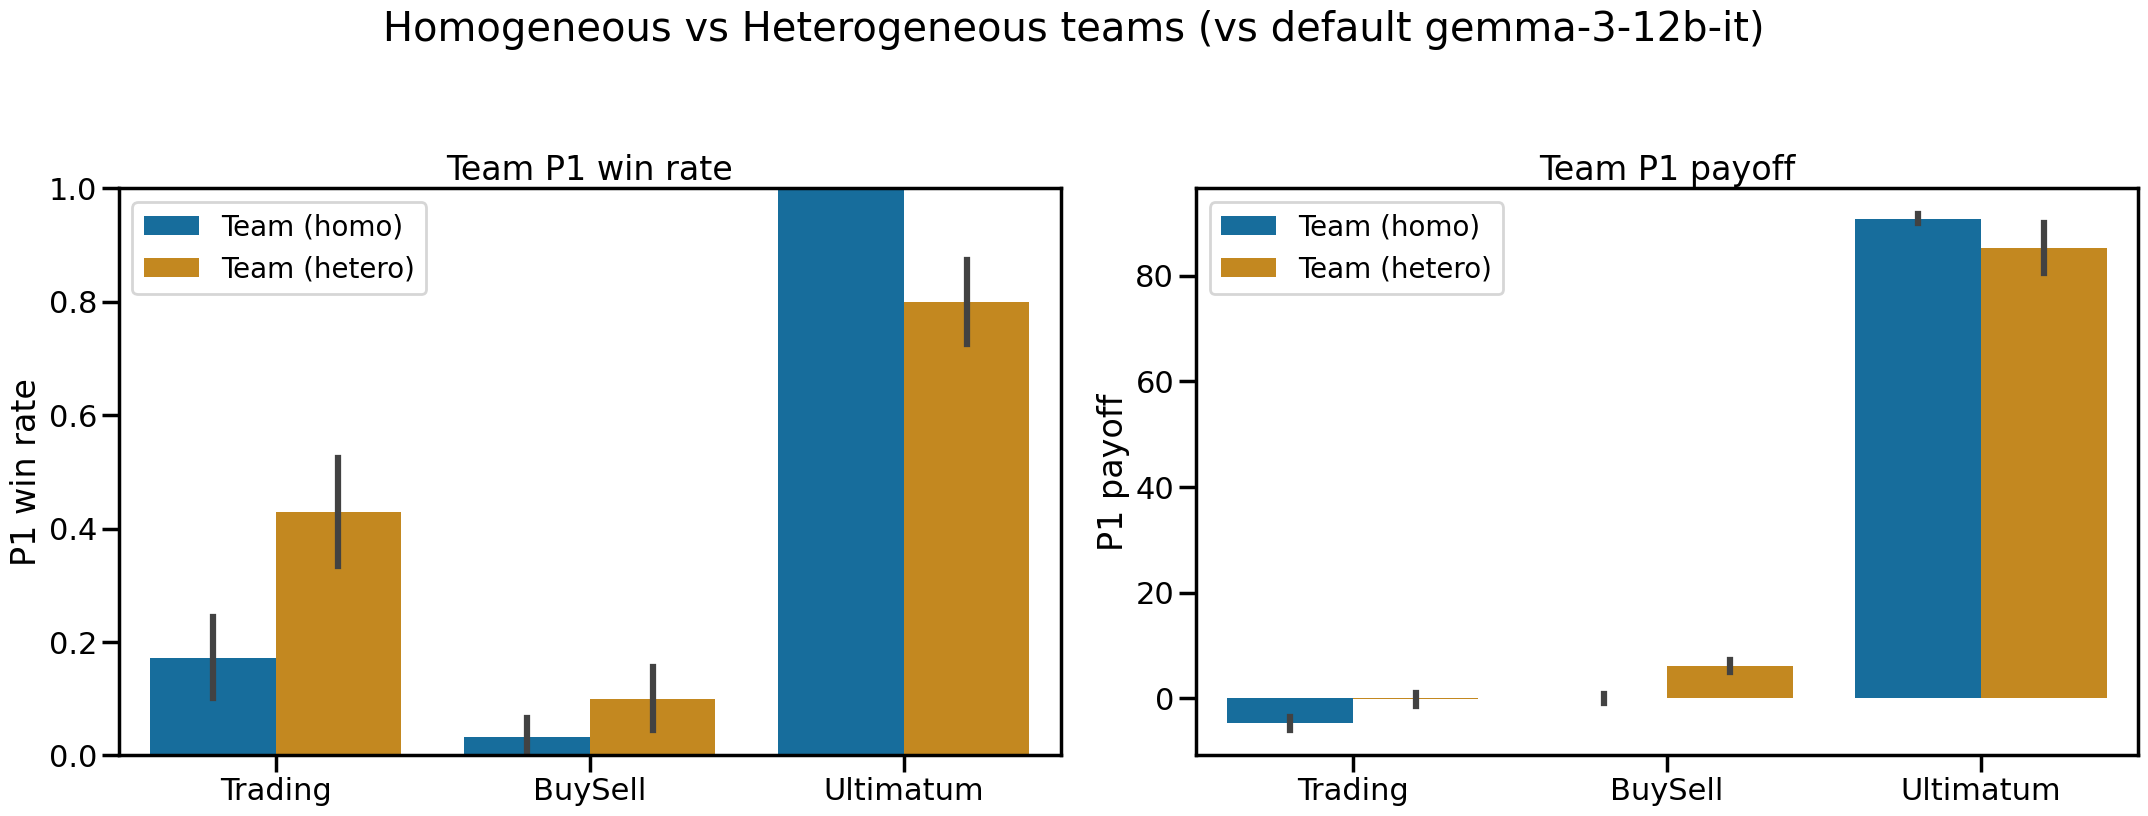

In [27]:
teams = df[df["strategy"].isin(["Team (homo)", "Team (hetero)"])].copy()
teams["strategy"] = teams["strategy"].cat.remove_unused_categories()

fig, axes = plt.subplots(1, 2, figsize=(22, 8))
sns.barplot(data=teams, x="game", y="win_1", hue="strategy", errorbar="se", ax=axes[0])
axes[0].set_title("Team P1 win rate")
axes[0].set_ylabel("P1 win rate"); axes[0].set_ylim(0, 1); axes[0].set_xlabel("")

sns.barplot(data=teams, x="game", y="payoff_1", hue="strategy", errorbar="se", ax=axes[1])
axes[1].set_title("Team P1 payoff")
axes[1].set_ylabel("P1 payoff"); axes[1].set_xlabel("")

for ax in axes:
    ax.set_xticklabels([GAME_LABEL[t.get_text()] for t in ax.get_xticklabels()])
    ax.legend(title="", fontsize="small")
plt.suptitle("Homogeneous vs Heterogeneous teams (vs default gemma-3-12b-it)", y=1.04)
plt.tight_layout()
plt.show()